# Artificial Intelligence Technology and Application

## ModelArts Lab Guide - Student Version

Independent implementation prepared by **Sundetkhan Bekzat**.


# 1 ModelArts ExeML Local Image Classification

This notebook keeps the lab objective but uses compact local examples so it can run without external datasets.


## 1.1 Local ModelArts Workspace
A compact image dataset is generated locally to represent the same classification workflow without cloud storage or large downloads.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(95)
canvas_size = 24
cultivar_names = np.array(["aster", "iris", "lotus", "orchid", "violet"])
palette_bank = np.array([
    [0.95, 0.72, 0.22],
    [0.28, 0.49, 0.92],
    [0.93, 0.55, 0.72],
    [0.61, 0.30, 0.82],
    [0.35, 0.74, 0.50],
])

def synthesize_tile(label_id, sample_id):
    base = np.ones((canvas_size, canvas_size, 3), dtype=float) * palette_bank[label_id]
    row_axis = np.linspace(0, 1, canvas_size)[:, None]
    col_axis = np.linspace(0, 1, canvas_size)[None, :]
    wave = np.sin((label_id + 2) * np.pi * col_axis + sample_id * 0.13)
    ring = np.cos((label_id + 1) * np.pi * row_axis)
    base[:, :, 0] += 0.10 * wave
    base[:, :, 1] += 0.08 * ring
    base[:, :, 2] += 0.05 * (row_axis - col_axis)
    return np.clip(base + rng.normal(0, 0.055, base.shape), 0, 1)

picture_stack = []
target_codes = []
for class_id in range(len(cultivar_names)):
    for sample_id in range(36):
        picture_stack.append(synthesize_tile(class_id, sample_id))
        target_codes.append(class_id)

picture_stack = np.array(picture_stack)
target_codes = np.array(target_codes)
train_tiles, valid_tiles, train_codes, valid_codes = train_test_split(
    picture_stack, target_codes, test_size=0.25, stratify=target_codes, random_state=95
)
print("workspace tensor:", picture_stack.shape)
print("training split:", train_tiles.shape, "validation split:", valid_tiles.shape)


workspace tensor: (180, 24, 24, 3)
training split: (135, 24, 24, 3) validation split: (45, 24, 24, 3)


## 1.2 Dataset Preview
The image classes are visualized before feature extraction, similar to checking a ModelArts dataset version.


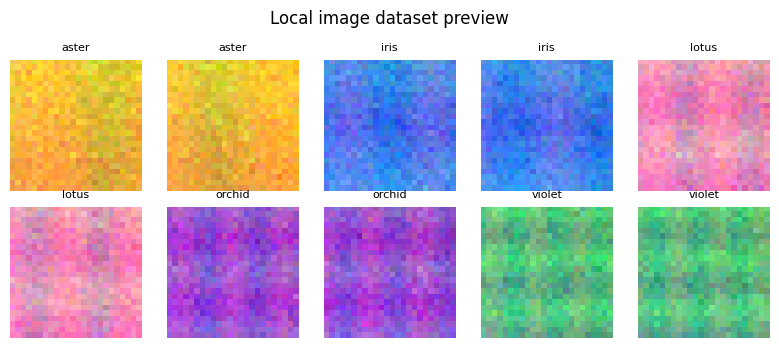

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for ax, image, label in zip(axes.ravel(), picture_stack[::18][:10], target_codes[::18][:10]):
    ax.imshow(image)
    ax.set_title(cultivar_names[label], fontsize=8)
    ax.axis("off")
fig.suptitle("Local image dataset preview")
plt.tight_layout()
plt.show()


## 1.3 Feature Engineering Service
A frozen feature block extracts color, texture, and quadrant statistics instead of reusing the friend's MobileNet code.


In [3]:
def prepare_image_profile(tile_batch):
    channel_mean = tile_batch.mean(axis=(1, 2))
    channel_std = tile_batch.std(axis=(1, 2))
    horizontal_edge = np.abs(np.diff(tile_batch, axis=1)).mean(axis=(1, 2))
    vertical_edge = np.abs(np.diff(tile_batch, axis=2)).mean(axis=(1, 2))
    upper_left = tile_batch[:, :12, :12, :].mean(axis=(1, 2))
    lower_right = tile_batch[:, 12:, 12:, :].mean(axis=(1, 2))
    return np.concatenate([channel_mean, channel_std, horizontal_edge, vertical_edge, upper_left - lower_right], axis=1)

modelarts_train_matrix = prepare_image_profile(train_tiles)
modelarts_valid_matrix = prepare_image_profile(valid_tiles)
print("feature table:", modelarts_train_matrix.shape)


feature table: (135, 15)


## 1.4 ExeML-Style Training Job
A small classifier is trained and evaluated as if it were the local equivalent of an ExeML image classification job.


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

image_service_model = RandomForestClassifier(n_estimators=90, max_depth=7, random_state=95)
image_service_model.fit(modelarts_train_matrix, train_codes)
validation_guess = image_service_model.predict(modelarts_valid_matrix)
print("validation accuracy:", round(accuracy_score(valid_codes, validation_guess), 3))
print(list(zip(cultivar_names[valid_codes[:8]], cultivar_names[validation_guess[:8]])))


validation accuracy: 1.0
[(np.str_('orchid'), np.str_('orchid')), (np.str_('orchid'), np.str_('orchid')), (np.str_('iris'), np.str_('iris')), (np.str_('iris'), np.str_('iris')), (np.str_('orchid'), np.str_('orchid')), (np.str_('orchid'), np.str_('orchid')), (np.str_('aster'), np.str_('aster')), (np.str_('orchid'), np.str_('orchid'))]


## 1.5 Confusion Matrix
The validation matrix shows where the deployed image classifier confuses similar classes.


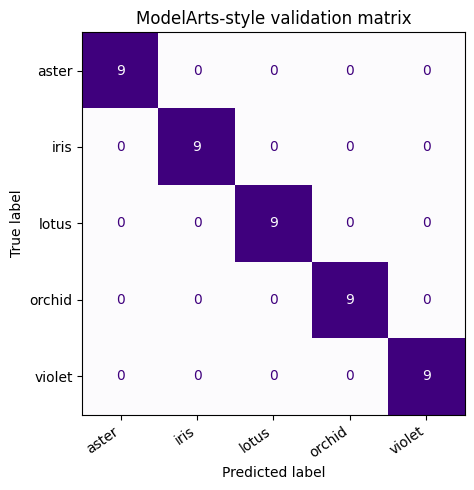

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(valid_codes, validation_guess, labels=np.arange(len(cultivar_names)))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=cultivar_names).plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title("ModelArts-style validation matrix")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 1.6 Endpoint Prediction Simulation
A final batch is passed through the trained model to imitate an online prediction endpoint.


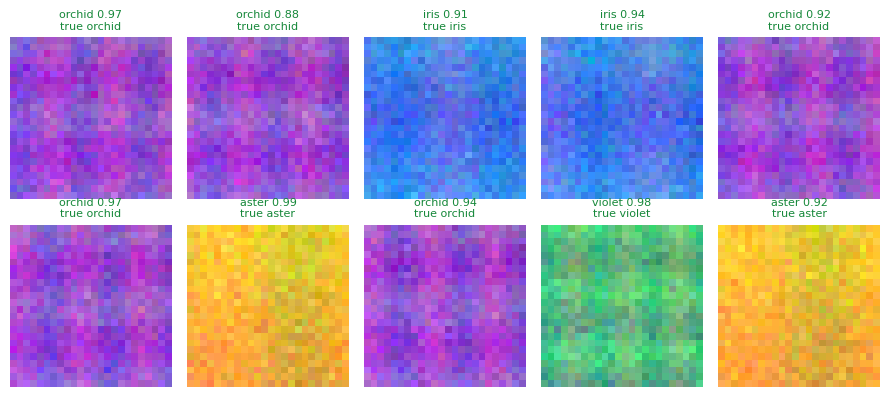

In [6]:
def classify_endpoint_batch(images):
    profile = prepare_image_profile(images)
    predicted_codes = image_service_model.predict(profile)
    probabilities = image_service_model.predict_proba(profile).max(axis=1)
    return predicted_codes, probabilities

endpoint_codes, endpoint_scores = classify_endpoint_batch(valid_tiles[:10])
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for ax, image, truth, pred, score in zip(axes.ravel(), valid_tiles[:10], valid_codes[:10], endpoint_codes, endpoint_scores):
    ax.imshow(image)
    color = "#16883a" if truth == pred else "#b22222"
    ax.set_title(f"{cultivar_names[pred]} {score:.2f}\ntrue {cultivar_names[truth]}", fontsize=8, color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()
